In [1]:
from PBR import PBR
from KineticModel import KineticModel
from Reaction import Reaction
import numpy as np
from y_n import y_n
from upsilon_n import upsilon_n
from math import e
from sklearn.model_selection import ParameterGrid
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
parafins = [ 'methane', 'ethane', 'propane', 
             'butane', 'pentane', 'hexane', 
               'heptane', 'octane', 
             'nonane', 'decane', 'undecane', 'dodecane',
               'tridecane', 'tetradecane', 'pentadecane', 'hexadecane', 'heptadecane',
               'octadecane', 'nonadecane', 'eicosane', 'heneicosane', 'docosane',
               'tricosane', 'tetracosane', 'pentacosane',
               'hexacosane', 'heptacosane',
               'octacosane', 'nonacosane', 'triacontane',
             'hentriacontane', 'dotriacontane',
               'tritriacontane', 'tetratriacontane', 'pentatriacontane', 'hexatriacontane'
            ]

olefins = [ 'ethylene',
            'propene',
            '1-butene', '1-pentene', '1-hexene',
            '1-heptene', '1-octene', 
            '1-nonene', '1-decene',
            '1-undecene', '1-dodecene',
            '1-tridecene', '1-tetradecene', '1-pentadecene',
            '1-hexadecene', '1-heptadecene', '1-octadecene',
          ]

others = ['carbon monoxide', 'hydrogen', 'water', 'carbon dioxide']

In [3]:
def Mousavi(phi_220C):
    model_name = 'Mousavi'
    param_dict = {'k_ads': np.float64(1.397972209918762e-05),
                     'H_ads': np.float64(932.9790718460237),
                     'A_HCs': np.float64(955.0608601894231),
                     'E_HCs': np.float64(147203.9259840268),
                     'A_WGS': np.float64(2066275395.2988818),
                     'E_WGS': np.float64(164536.37699675243),
                     'a_WGS': np.float64(0.016649380568140318),
                     'b_WGS': np.float64(0.5269130869163346)}

    bnds = {
        'k_ads': (0, None), # 1/Pa
        'H_ads': (0, None), # J/mol
        'A_HCs': (0, None), # mol/s/kg/Pa²
        'E_HCs': (0, None), # J/mol
        'A_WGS': (0, None), # mol/s/kg/Pa²
        'E_WGS': (0, None), # J/mol
        'a_WGS': (None, None),
        'b_WGS': (None, None),
    }

    model = KineticModel(model_name, params = param_dict, bnds = bnds)

    def rate_WGS(param_dict, T, P, x, F, K, eq_distance, R, data):
        P_CO = x['carbon monoxide']*P
        P_H2O = x['water']*P
        P_CO2 = x['carbon dioxide']*P
        P_H2 = x['hydrogen']*P

        A_WGS = param_dict['A_WGS']
        E_WGS = param_dict['E_WGS']
        a = param_dict['a_WGS']
        b = param_dict['b_WGS']

        K_WGS = 1.45e-2 * np.exp( 4.62e3 / T )
        k_WGS = A_WGS * np.exp ( - E_WGS / ( 8.314 * T ) )

        phi = phi_220C * ( ( 493 / T ) * np.exp( - ( E_WGS / R ) * ( 1/T - 1/493 ) ) ) ** (1/2)
        eff = np.tanh(phi)/phi

        rate_WGS = eff * ( k_WGS * P_CO**a * P_H2O**b ) * eq_distance
        return rate_WGS

    WGS = Reaction(
                     name = 'WGS',
                     stoic = {
                             'carbon monoxide': -1,
                             'water': -1,
                             'carbon dioxide': 1,
                             'hydrogen': 1,
                         },
                     base_component = 'carbon monoxide',
                     rate_function = rate_WGS,
                     rate_unit = 'mol/s/kg',
        )

    model.add_reaction(WGS)

    n_parafins = {}
    for i, parafin in enumerate(parafins):
        n = i + 1
        n_parafins[parafin] = n

    n_olefins = {}
    for i, olefin in enumerate(olefins):
        n = i + 1
        n_olefins[olefin] = n

    for parafin in n_parafins:
        n = n_parafins[parafin]
        def rate_n_para(param_dict, T, P, x, F, K, eq_distance, R, data, n = n):
            P_H2 = x['hydrogen']*P
            P_CO = x['carbon monoxide']*P

            k_ads = param_dict['k_ads']
            H_ads = param_dict['H_ads']
            A_HCs = param_dict['A_HCs']
            E_HCs = param_dict['E_HCs']

            F_H2 = x['hydrogen']*F
            F_CO = x['carbon monoxide']*F

            K_ads = k_ads * e**(-H_ads / (R * T))
            k_HCs = A_HCs * e**(-E_HCs / (R * T))

            phi = phi_220C * ( ( 493 / T ) * np.exp( - ( E_HCs / R ) * ( 1/T - 1/493 ) ) ) ** (1/2)
            eff = np.tanh(phi)/phi
            
            r     = eff * y_n(n, T) * upsilon_n(n, T) * k_HCs * P_H2**0.75 * P_CO / (1 + K_ads * P_CO)**2
            return r

        reaction = Reaction(
                     name = parafin,
                     stoic = {
                             'carbon monoxide': -n,
                             'hydrogen': -(2*n + 1),
                              parafin: 1,
                             'water': n,
                         },
                     base_component = parafin,
                     rate_function = rate_n_para,
                     rate_unit = 'mol/s/kg',
        )

        model.add_reaction(reaction)

    for olefin in n_olefins:
        n = n_olefins[olefin]
        def rate_n_ole(param_dict, T, P, x, F, K, eq_distance, R, data, n = n):
            P_H2 = x['hydrogen']*P
            P_CO = x['carbon monoxide']*P

            k_ads = param_dict['k_ads']
            H_ads = param_dict['H_ads']
            A_HCs = param_dict['A_HCs']
            E_HCs = param_dict['E_HCs']

            F_H2 = x['hydrogen']*F
            F_CO = x['carbon monoxide']*F

            K_ads = k_ads * e**(-H_ads / (R * T))
            k_HCs = A_HCs * e**(-E_HCs / (R * T))

            phi = phi_220C * ( ( 493 / T ) * np.exp( - ( E_HCs / R ) * ( 1/T - 1/493 ) ) ) ** (1/2)
            eff = np.tanh(phi)/phi
            
            r     = eff * y_n(n, T) * (1 - upsilon_n(n, T)) * k_HCs * P_H2**0.75 * P_CO / (1 + K_ads * P_CO)**2
            return r

        reaction = Reaction(
                     name = olefin,
                     stoic = {
                             'carbon monoxide': -n,
                             'hydrogen': -(2*n),
                              olefin: 1,
                             'water': n,
                         },
                     base_component = olefin,
                     rate_function = rate_n_ole,
                     rate_unit = 'mol/s/kg',
        )

        model.add_reaction(reaction)
    return model

In [4]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO = 2
x_CO = 1 / ( 1 + H2_CO )
x_H2 = 1 - x_CO

# create reactor object
T0 = 250
n_tubes = 60

x0 = {
                  'carbon monoxide': x_CO,
                  'hydrogen' : x_H2,
              }

reactor = PBR(T0 = (T0, 'C'), 
              P0 = (20, 'bar'), 
              x0 = x0, 
              F0 = (F0 / n_tubes, 'mol/s'),
              isothermal = False, 
              ergun = True,
              WT = (74 / n_tubes, 'kg'), 
              W_steps = 100,
              U = (300, 'W/m2/K'),
              D = (45.1, 'mm'),
              Dp = (4, 'mm'),
              pellet_density = (2530, 'kg/m3'),
              Ta = (T0, 'C'),
              liquid_phase = False,
              units = 'SI',
              solver_method = 'BDF',
              rtol = 1e-5, atol = 1e-7,
              calculate_equilibrium = False,
              equilibrium_obj_fun_tolerance = 1e-12,
              log = True,
             )

Mousavi_model = Mousavi(phi_220C:=4)
reactor.add_model(Mousavi_model)
reactor.solve()

In [5]:
?reactor.plot

Signature:
reactor.plot(
    model_name='',
    figsize=(10, 6),
    leg_fontsize=8,
    max_legends=10,
    yscale='linear',
    leg_loc=[0, 0, 0, 0, 0],
    plot_conversions=[],
)
Docstring: <no docstring>
File:      ~/GoogleDrive/uem/Doutorado/Ensaios/SAF/SAF_8_08_08_2025/SAF_kinetics_paper_code_with_WGS/PBR.py
Type:      method

No model selected, plotting the last model.
Too many legend labels, limiting the size to 10, others are hidden.


<Figure size 640x480 with 0 Axes>

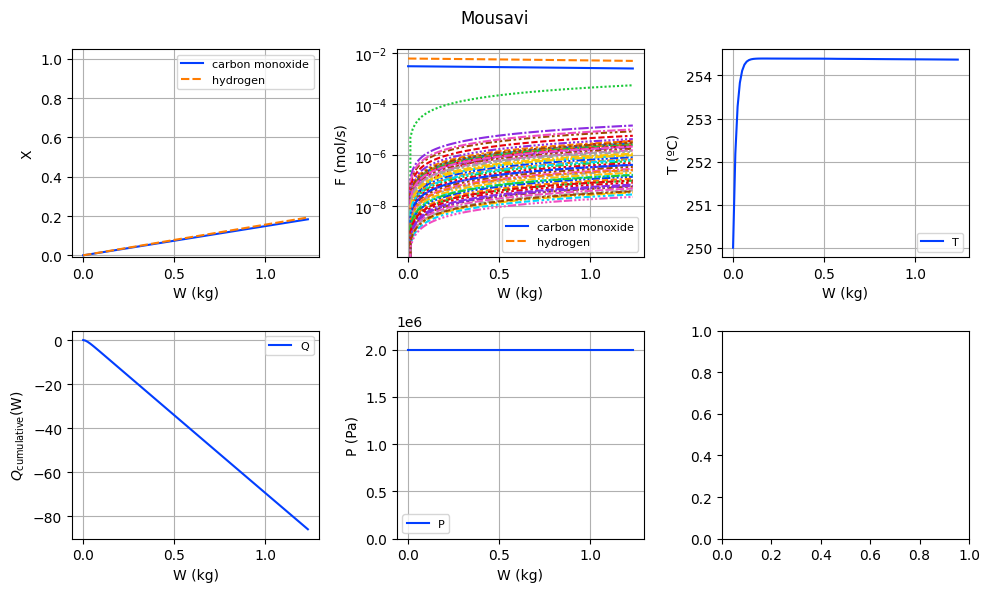

In [8]:
reactor.plot(plot_conversions = ['hydrogen', 'carbon monoxide'], yscale = 'log', max_legends = 2)